── ORIGINAL DATASET ──
    PatientID     Name   Age Gender       Disease     BP
0           1    Alice  25.0      F      Diabetes  130.0
1           2      Bob   NaN      M  Hypertension  140.0
2           3  Charlie  45.0      M      Diabetes    NaN
3           4    Diana  60.0      F        Asthma  120.0
4           5    Ethan  33.0      M  Hypertension  145.0
5           6    Fiona   NaN      F          None  130.0
6           7   George  72.0      M      Diabetes    NaN
7           8   Hannah  29.0      F           Flu  118.0
8           9     Ivan  55.0      M        Asthma  135.0
9          10    Julia  41.0      F      Diabetes  128.0
10         11    Kevin  38.0      M  Hypertension  142.0
11         12    Laura   NaN      F      Diabetes  126.0
12         13     Mike  67.0      M          None  138.0
13         14     Nina  50.0      F        Asthma    NaN
14         15    Oscar  44.0      M      Diabetes  132.0
15         16    Priya  31.0      F           Flu  119.0
16      

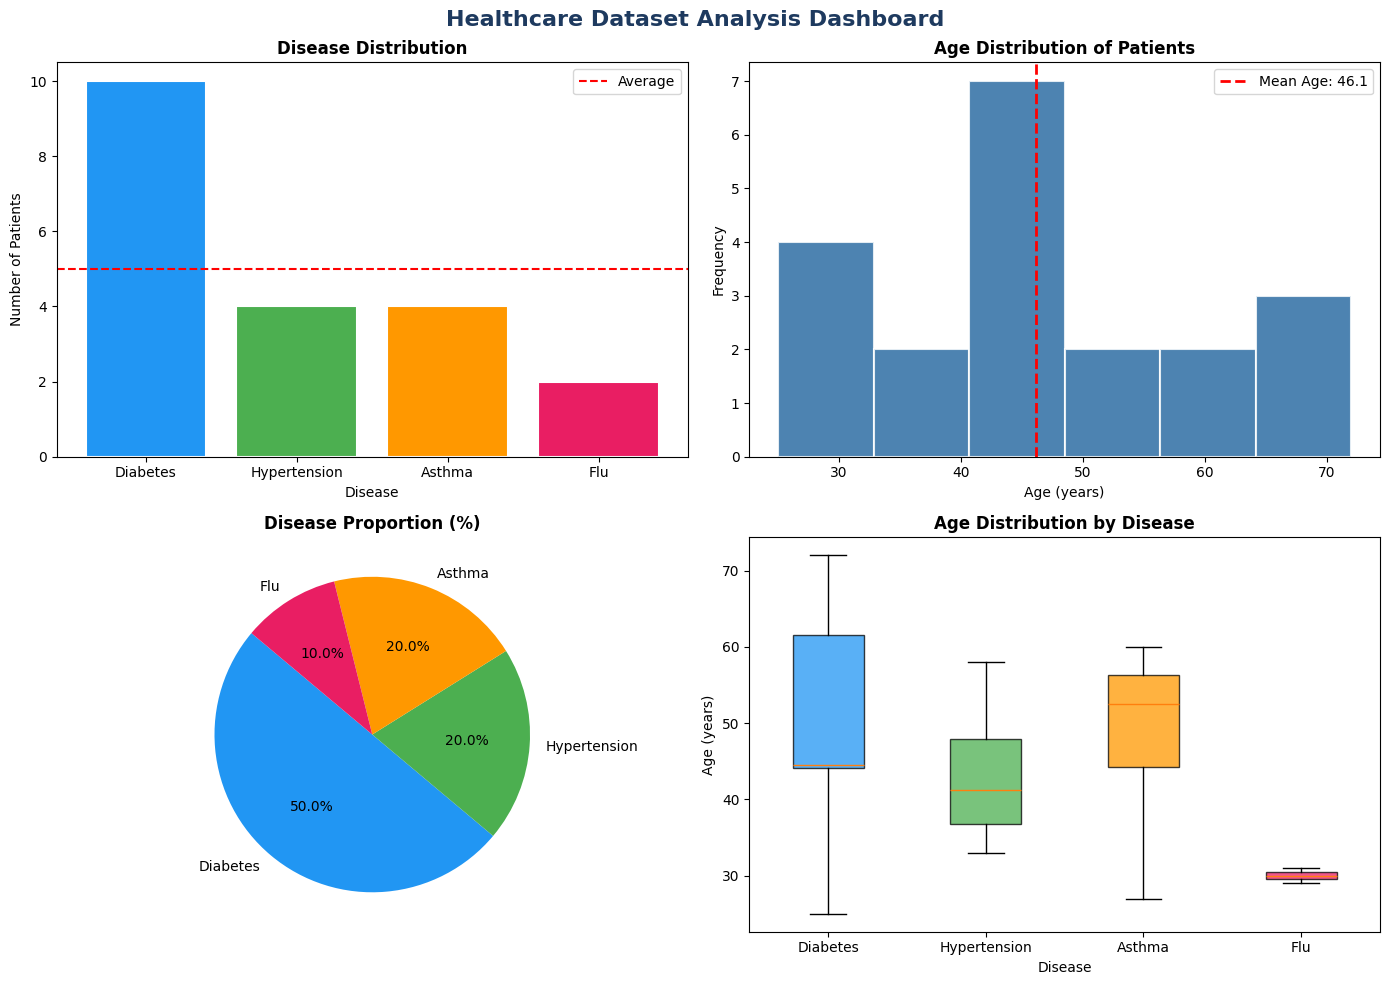


Visualization saved as healthcare_analysis.png


In [2]:
# ================================================================
# Healthcare Dataset Analysis
# Subject: Data Science and Analytics | Assignment 1 - Q3
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ── STEP 1: Create / Load Dataset ──────────────────────────────────
data = {
    'PatientID': range(1, 21),
    'Name':    ['Alice','Bob','Charlie','Diana','Ethan','Fiona',
               'George','Hannah','Ivan','Julia','Kevin','Laura',
               'Mike','Nina','Oscar','Priya','Quinn','Rita',
               'Sam','Tina'],
    'Age':     [25, None, 45, 60, 33, None, 72, 29, 55, 41,
               38, None, 67, 50, 44, 31, 58, 27, None, 70],
    'Gender':  ['F','M','M','F','M','F','M','F','M','F',
               'M','F','M','F','M','F','M','F','M','F'],
    'Disease': ['Diabetes','Hypertension','Diabetes','Asthma',
               'Hypertension',None,'Diabetes','Flu','Asthma',
               'Diabetes','Hypertension','Diabetes',None,
               'Asthma','Diabetes','Flu','Hypertension',
               'Asthma','Diabetes','Diabetes'],
    'BP':      [130, 140, None, 120, 145, 130, None, 118,
               135, 128, 142, 126, 138, None, 132, 119,
               141, 125, 137, 129]
}

df = pd.DataFrame(data)
print('── ORIGINAL DATASET ──')
print(df.to_string())
print(f'\nShape: {df.shape}')
print(f'Missing values:\n{df.isnull().sum()}')

# ── STEP 2: Handle Missing Values ──────────────────────────────────
# Fill missing Age with median age
median_age = df['Age'].median()
df['Age'].fillna(median_age, inplace=True)

# Fill missing Disease with mode (most common disease)
mode_disease = df['Disease'].mode()[0]
df['Disease'].fillna(mode_disease, inplace=True)

# Fill missing BP with median BP
df['BP'].fillna(df['BP'].median(), inplace=True)

print('\n── AFTER HANDLING MISSING VALUES ──')
print(f'Missing values:\n{df.isnull().sum()}')

# ── STEP 3: Calculate Average Age ──────────────────────────────────
avg_age = df['Age'].mean()
print(f'\n── STATISTICS ──')
print(f'Average Age of Patients : {avg_age:.2f} years')
print(f'Minimum Age             : {df["Age"].min()}')
print(f'Maximum Age             : {df["Age"].max()}')

# ── STEP 4: Identify Most Common Disease ───────────────────────────
disease_counts = df['Disease'].value_counts()
most_common = disease_counts.idxmax()
print(f'\nDisease Distribution:')
print(disease_counts.to_string())
print(f'\nMost Common Disease     : {most_common} ({disease_counts[most_common]} patients)')

# ── STEP 5: Visualizations ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Healthcare Dataset Analysis Dashboard',
             fontsize=16, fontweight='bold', color='#1E3A5F')

colors = ['#2196F3','#4CAF50','#FF9800','#E91E63']

# Plot 1: Disease Distribution (Bar Chart)
axes[0, 0].bar(disease_counts.index, disease_counts.values,
               color=colors, edgecolor='white', linewidth=1.5)
axes[0, 0].set_title('Disease Distribution', fontweight='bold')
axes[0, 0].set_xlabel('Disease')
axes[0, 0].set_ylabel('Number of Patients')
axes[0, 0].axhline(y=disease_counts.mean(), color='red',
                   linestyle='--', label='Average')
axes[0, 0].legend()

# Plot 2: Age Distribution (Histogram)
axes[0, 1].hist(df['Age'], bins=6, color='#2E6DA4',
                edgecolor='white', linewidth=1.5, alpha=0.85)
axes[0, 1].axvline(avg_age, color='red', linestyle='--',
                   linewidth=2, label=f'Mean Age: {avg_age:.1f}')
axes[0, 1].set_title('Age Distribution of Patients', fontweight='bold')
axes[0, 1].set_xlabel('Age (years)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()

# Plot 3: Disease Proportion (Pie Chart)
axes[1, 0].pie(disease_counts.values, labels=disease_counts.index,
               autopct='%1.1f%%', colors=colors, startangle=140)
axes[1, 0].set_title('Disease Proportion (%)', fontweight='bold')

# Plot 4: Age by Disease (Box Plot)
diseases = df['Disease'].unique()
age_by_disease = [df[df['Disease']==d]['Age'].values for d in diseases]
bp = axes[1, 1].boxplot(age_by_disease, patch_artist=True, labels=diseases)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[1, 1].set_title('Age Distribution by Disease', fontweight='bold')
axes[1, 1].set_xlabel('Disease')
axes[1, 1].set_ylabel('Age (years)')

plt.tight_layout()
plt.savefig('healthcare_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nVisualization saved as healthcare_analysis.png')


Simulating 1,000,000 records...
Generated 3,000,000 records in 0.91 seconds

═══ SOCIAL MEDIA STATISTICS ═══
  Average Post Likes     : 49.56
  Std Dev of Likes       : 50.08
  Top Platform           : Instagram
  Positive Sentiment %   : 45.0%

═══ IoT SENSOR STATISTICS ═══
  Avg Temperature (°C)   : 37.50
  Avg Pressure (kPa)     : 101.30
  Max Vibration          : 2.4531
  Low Battery (<20%) cnt : 110,812

═══ TRANSACTION STATISTICS ═══
  Total Transaction Value: ₹459,179,127.95
  Average Transaction    : ₹459.18
  Median Transaction     : ₹148.32
  Fraud Rate             : 2.01%
  Fraudulent Count       : 20,092
  Top Category           : Food


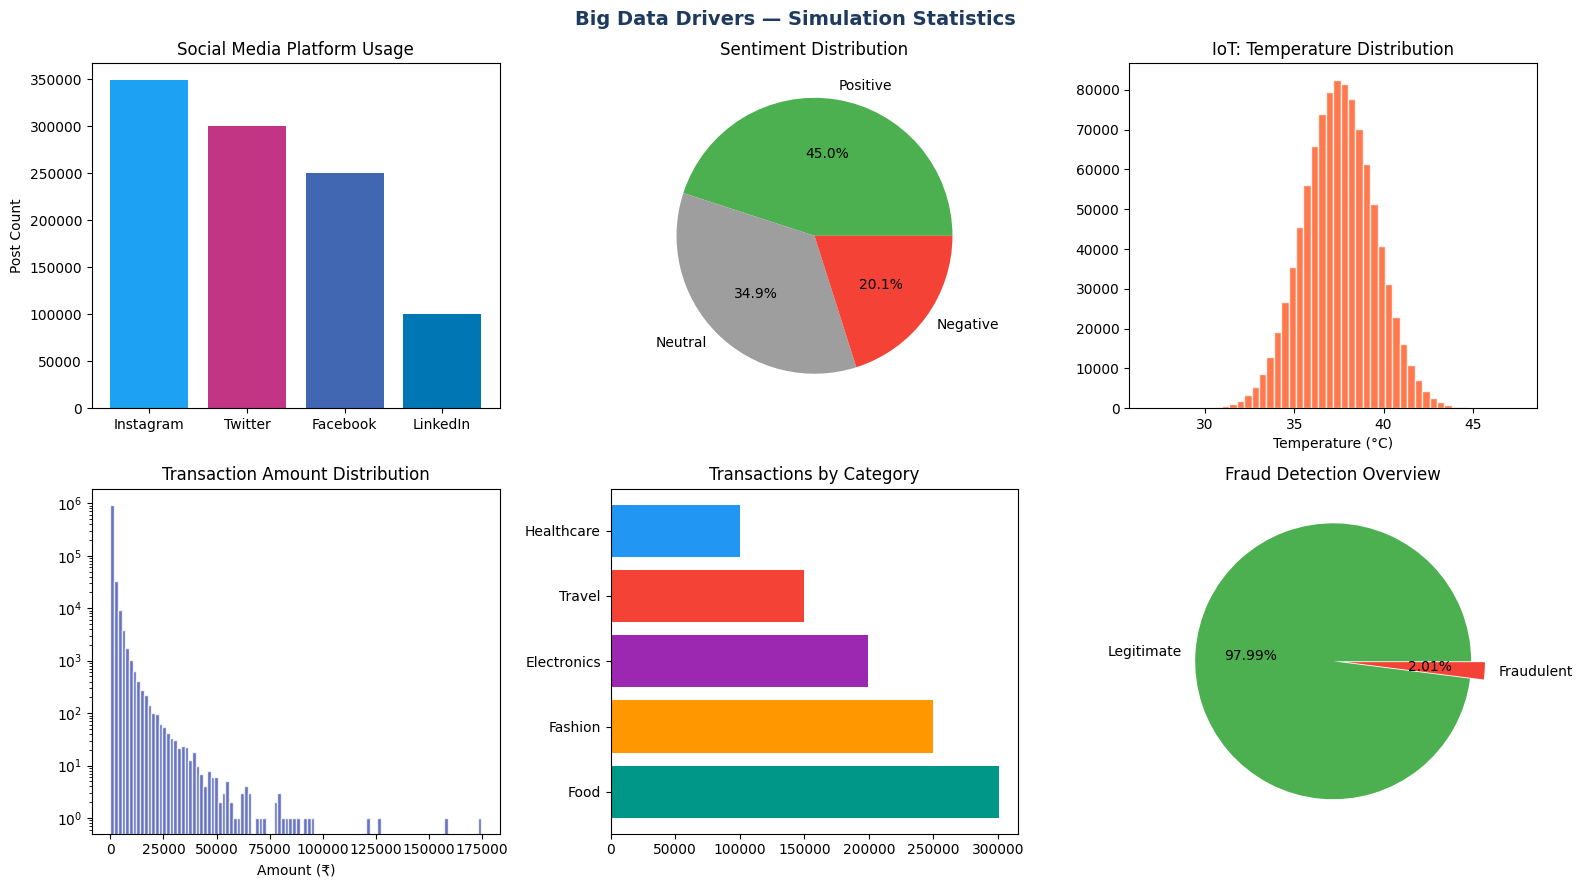

Simulation charts saved.


In [3]:
# ================================================================
# Big Data Simulation — Large-Scale Data Generation & Statistics
# Subject: Data Science and Analytics | Assignment 1 - Q4
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

# ── Configuration ──────────────────────────────────────────────────
NUM_RECORDS = 1_000_000  # 1 Million records
np.random.seed(42)

print(f'Simulating {NUM_RECORDS:,} records...')
start = time.time()

# ── SOCIAL MEDIA Data Simulation ───────────────────────────────────
social_media = pd.DataFrame({
    'user_id':       np.random.randint(100000, 999999, NUM_RECORDS),
    'post_likes':    np.random.exponential(50, NUM_RECORDS).astype(int),
    'shares':        np.random.poisson(5, NUM_RECORDS),
    'sentiment':     np.random.choice(['Positive','Neutral','Negative'],
                         NUM_RECORDS, p=[0.45, 0.35, 0.20]),
    'platform':      np.random.choice(['Twitter','Instagram',
                         'Facebook','LinkedIn'],
                         NUM_RECORDS, p=[0.30,0.35,0.25,0.10]),
})

# ── IoT Sensor Data Simulation ─────────────────────────────────────
iot_data = pd.DataFrame({
    'device_id':     np.random.randint(1000, 9999, NUM_RECORDS),
    'temperature':   np.random.normal(37.5, 2.0, NUM_RECORDS),
    'pressure':      np.random.normal(101.3, 5.0, NUM_RECORDS),
    'vibration':     np.abs(np.random.normal(0, 0.5, NUM_RECORDS)),
    'battery_pct':   np.random.uniform(10, 100, NUM_RECORDS),
})

# ── Transaction Data Simulation ────────────────────────────────────
transactions = pd.DataFrame({
    'txn_id':        np.arange(1, NUM_RECORDS + 1),
    'amount':        np.abs(np.random.lognormal(5, 1.5, NUM_RECORDS)),
    'category':      np.random.choice(['Electronics','Food','Fashion',
                         'Healthcare','Travel'],
                         NUM_RECORDS, p=[0.20,0.30,0.25,0.10,0.15]),
    'is_fraud':      np.random.binomial(1, 0.02, NUM_RECORDS),
})

elapsed = time.time() - start
total_rows = len(social_media) + len(iot_data) + len(transactions)
print(f'Generated {total_rows:,} records in {elapsed:.2f} seconds')

# ── BASIC STATISTICS ───────────────────────────────────────────────
print('\n═══ SOCIAL MEDIA STATISTICS ═══')
print(f'  Average Post Likes     : {social_media["post_likes"].mean():.2f}')
print(f'  Std Dev of Likes       : {social_media["post_likes"].std():.2f}')
print(f'  Top Platform           : {social_media["platform"].value_counts().idxmax()}')
print(f'  Positive Sentiment %   : {(social_media["sentiment"]=="Positive").mean()*100:.1f}%')

print('\n═══ IoT SENSOR STATISTICS ═══')
print(f'  Avg Temperature (°C)   : {iot_data["temperature"].mean():.2f}')
print(f'  Avg Pressure (kPa)     : {iot_data["pressure"].mean():.2f}')
print(f'  Max Vibration          : {iot_data["vibration"].max():.4f}')
print(f'  Low Battery (<20%) cnt : {(iot_data["battery_pct"]<20).sum():,}')

print('\n═══ TRANSACTION STATISTICS ═══')
print(f'  Total Transaction Value: ₹{transactions["amount"].sum():,.2f}')
print(f'  Average Transaction    : ₹{transactions["amount"].mean():.2f}')
print(f'  Median Transaction     : ₹{transactions["amount"].median():.2f}')
print(f'  Fraud Rate             : {transactions["is_fraud"].mean()*100:.2f}%')
print(f'  Fraudulent Count       : {transactions["is_fraud"].sum():,}')
print(f'  Top Category           : {transactions["category"].value_counts().idxmax()}')

# ── VISUALIZATIONS ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Big Data Drivers — Simulation Statistics',
             fontsize=14, fontweight='bold', color='#1E3A5F')

# 1. Platform Distribution
plat_counts = social_media['platform'].value_counts()
axes[0,0].bar(plat_counts.index, plat_counts.values,
              color=['#1DA1F2','#C13584','#4267B2','#0077B5'])
axes[0,0].set_title('Social Media Platform Usage')
axes[0,0].set_ylabel('Post Count')

# 2. Sentiment Pie
sent = social_media['sentiment'].value_counts()
axes[0,1].pie(sent, labels=sent.index, autopct='%1.1f%%',
              colors=['#4CAF50','#9E9E9E','#F44336'])
axes[0,1].set_title('Sentiment Distribution')

# 3. IoT Temperature Histogram
axes[0,2].hist(iot_data['temperature'], bins=50,
               color='#FF5722', alpha=0.8, edgecolor='white')
axes[0,2].set_title('IoT: Temperature Distribution')
axes[0,2].set_xlabel('Temperature (°C)')

# 4. Transaction Amount Distribution (log scale)
axes[1,0].hist(transactions['amount'], bins=100,
               color='#3F51B5', alpha=0.8, edgecolor='white')
axes[1,0].set_title('Transaction Amount Distribution')
axes[1,0].set_xlabel('Amount (₹)')
axes[1,0].set_yscale('log')

# 5. Category Sales
cat_counts = transactions['category'].value_counts()
axes[1,1].barh(cat_counts.index, cat_counts.values,
               color=['#009688','#FF9800','#9C27B0','#F44336','#2196F3'])
axes[1,1].set_title('Transactions by Category')

# 6. Fraud vs Legit Pie
fraud_counts = transactions['is_fraud'].value_counts()
axes[1,2].pie([fraud_counts.get(0,0), fraud_counts.get(1,0)],
              labels=['Legitimate','Fraudulent'],
              autopct='%1.2f%%', colors=['#4CAF50','#F44336'],
              explode=[0, 0.1])
axes[1,2].set_title('Fraud Detection Overview')

plt.tight_layout()
plt.savefig('bigdata_simulation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Simulation charts saved.')


── DATASET SAMPLE ──
 Study_Hours     Marks
    5.119941 57.587287
   11.457857 93.142558
    9.051933 72.384621
    7.585243 66.812263
    2.716205 36.943015
    2.715940 36.402459
    1.638920 43.069754
   10.527938 90.777128
    7.612265 67.629265
    8.788798 79.965189

Dataset Shape: (80, 2)

Descriptive Statistics:
       Study_Hours   Marks
count        80.00   80.00
mean          6.12   60.56
std           3.36   18.53
min           1.06   26.00
25%           3.03   46.13
50%           5.80   59.78
75%           9.16   75.47
max          11.86  100.00

Correlation (Study Hours vs Marks): 0.9513

Train Size: 64 | Test Size: 16

── MODEL PARAMETERS ──
Intercept (β₀)  : 28.7544
Coefficient (β₁): 5.1607
Equation        : Marks = 28.75 + 5.16 × Study_Hours

── EVALUATION METRICS ──
Train R²  : 0.8962 (89.62%)
Test R²   : 0.9362  (93.62%)
RMSE      : 4.7372 marks
MAE       : 3.7341 marks

── PREDICTION EXAMPLES ──
  Study Hours:  2h → Predicted Marks: 39.1/100
  Study Hours:  4h → Pr

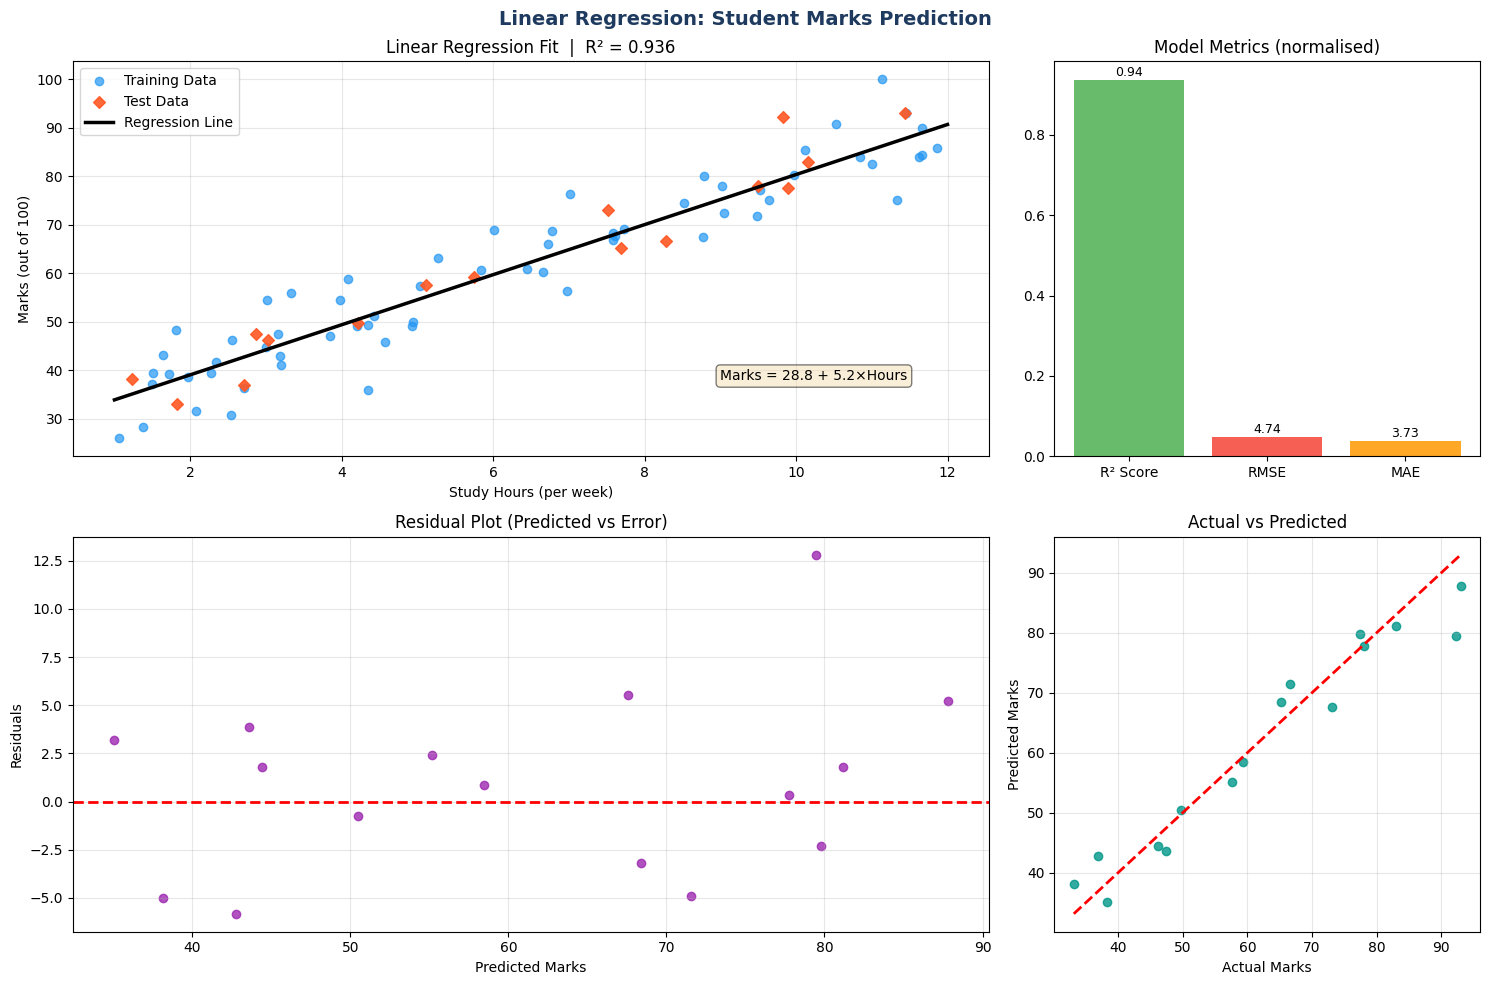


All charts saved successfully.


In [4]:
# ================================================================
# Linear Regression: Predicting Student Marks from Study Hours
# Subject: Data Science and Analytics | Assignment 1 - Q5
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                              r2_score)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ── STEP 1: Problem Formulation ────────────────────────────────────
# Goal: Build a model to predict student marks (0-100) based on
#       weekly study hours. Evaluate with R² and RMSE metrics.

# ── STEP 2: Dataset Creation ───────────────────────────────────────
np.random.seed(42)
n = 80
study_hours = np.random.uniform(1, 12, n)
# Marks: base 30 + 5*hours + noise (realistic academic model)
marks = 30 + 5 * study_hours + np.random.normal(0, 6, n)
marks = np.clip(marks, 0, 100)  # Marks must be 0–100

df = pd.DataFrame({'Study_Hours': study_hours, 'Marks': marks})
print('── DATASET SAMPLE ──')
print(df.head(10).to_string(index=False))
print(f'\nDataset Shape: {df.shape}')
print(f'\nDescriptive Statistics:')
print(df.describe().round(2))

# ── STEP 3: Exploratory Data Analysis ─────────────────────────────
corr = df['Study_Hours'].corr(df['Marks'])
print(f'\nCorrelation (Study Hours vs Marks): {corr:.4f}')

# ── STEP 4: Data Splitting ────────────────────────────────────────
X = df[['Study_Hours']].values
y = df['Marks'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'\nTrain Size: {len(X_train)} | Test Size: {len(X_test)}')

# ── STEP 5: Model Training ─────────────────────────────────────────
model = LinearRegression()
model.fit(X_train, y_train)

print(f'\n── MODEL PARAMETERS ──')
print(f'Intercept (β₀)  : {model.intercept_:.4f}')
print(f'Coefficient (β₁): {model.coef_[0]:.4f}')
print(f'Equation        : Marks = {model.intercept_:.2f} + {model.coef_[0]:.2f} × Study_Hours')

# ── STEP 6: Predictions & Evaluation ──────────────────────────────
y_pred_test  = model.predict(X_test)
y_pred_train = model.predict(X_train)

rmse_test  = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test   = mean_absolute_error(y_test, y_pred_test)
r2_test    = r2_score(y_test, y_pred_test)
r2_train   = r2_score(y_train, y_pred_train)

print(f'\n── EVALUATION METRICS ──')
print(f'Train R²  : {r2_train:.4f} ({r2_train*100:.2f}%)')
print(f'Test R²   : {r2_test:.4f}  ({r2_test*100:.2f}%)')
print(f'RMSE      : {rmse_test:.4f} marks')
print(f'MAE       : {mae_test:.4f} marks')

# ── STEP 7: Prediction Examples ───────────────────────────────────
print(f'\n── PREDICTION EXAMPLES ──')
for h in [2, 4, 6, 8, 10, 12]:
    pred = model.predict([[h]])[0]
    print(f'  Study Hours: {h:2d}h → Predicted Marks: {min(pred,100):.1f}/100')

# ── STEP 8: Visualizations ────────────────────────────────────────
fig = plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(2, 3, figure=fig)
fig.suptitle('Linear Regression: Student Marks Prediction',
             fontsize=14, fontweight='bold', color='#1E3A5F')

# Plot 1: Regression Line
ax1 = fig.add_subplot(gs[0, :2])
ax1.scatter(X_train, y_train, color='#2196F3', alpha=0.7,
            label='Training Data', zorder=3)
ax1.scatter(X_test, y_test, color='#FF5722', alpha=0.9,
            label='Test Data', marker='D', zorder=4)
x_line = np.linspace(1, 12, 200).reshape(-1, 1)
ax1.plot(x_line, model.predict(x_line), 'k-',
         linewidth=2.5, label='Regression Line', zorder=5)
ax1.set_xlabel('Study Hours (per week)')
ax1.set_ylabel('Marks (out of 100)')
ax1.set_title(f'Linear Regression Fit  |  R² = {r2_test:.3f}')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.text(9, 38, f'Marks = {model.intercept_:.1f} + {model.coef_[0]:.1f}×Hours',
         fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 2: Metrics Summary
ax2 = fig.add_subplot(gs[0, 2])
metrics = ['R² Score', 'RMSE', 'MAE']
values = [r2_test, rmse_test/100, mae_test/100]
colors_m = ['#4CAF50', '#F44336', '#FF9800']
bars = ax2.bar(metrics, values, color=colors_m, alpha=0.85)
ax2.set_title('Model Metrics (normalised)')
for bar, val, raw in zip(bars, values, [r2_test, rmse_test, mae_test]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{raw:.2f}', ha='center', fontsize=9)

# Plot 3: Residuals Plot
ax3 = fig.add_subplot(gs[1, :2])
residuals = y_test - y_pred_test
ax3.scatter(y_pred_test, residuals, color='#9C27B0', alpha=0.8)
ax3.axhline(0, color='red', linestyle='--', linewidth=2)
ax3.set_xlabel('Predicted Marks')
ax3.set_ylabel('Residuals')
ax3.set_title('Residual Plot (Predicted vs Error)')
ax3.grid(True, alpha=0.3)

# Plot 4: Actual vs Predicted
ax4 = fig.add_subplot(gs[1, 2])
ax4.scatter(y_test, y_pred_test, color='#009688', alpha=0.8)
ax4.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', linewidth=2)
ax4.set_xlabel('Actual Marks')
ax4.set_ylabel('Predicted Marks')
ax4.set_title('Actual vs Predicted')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('linear_regression_student.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nAll charts saved successfully.')
